# Different LLM Models Pipeline

This notebook first rebuilds `data/different_llm_models.xlsx` from `data/final results.xlsx`, then produces the boxplot-based analyses.

Analysis choices used here:

All plots below use only rows with `mode == "train"`.

1. Convergence is measured with normalized convergence AUC on standard train rows. The left subplot uses available `without optimizer` rows with `n_pop <= 10`; the right subplot uses available `with optimizer` rows with `n_pop <= 20`. The x-axis is ordered from the weakest to strongest model using a fixed smartness ranking. DeepSeek enters both panels through `S 4.1` for `without optimizer` and `S 3` for `with optimizer`. Smaller AUC means `avg_top1` falls faster toward the best observed cost for the same instance and optimizer setting. The boxplot below shows the first `n_pop` at which each LLM reaches the best observed cost for that instance, if it ever does.
2. Across-run variance is measured on the shared six-model train slice at `n_pop = 20` from `S 4.4 no opt extension`, using the coefficient of variation of the top-1 result across the 10 runs.
3. Optimizer impact is measured on matched standard train rows by comparing `avg_top1` with and without optimizer across all LLMs that have both settings.


---
### Data Preperation
---

In [2]:
from pathlib import Path
import pandas as pd
from different_llm_models_helpers import build_different_llm_workbook


In [3]:
SOURCE_WORKBOOK = Path("data/final results.xlsx")
OUTPUT_WORKBOOK = Path("data/different_llm_models.xlsx")
Path("plots").mkdir(exist_ok=True)

combined = build_different_llm_workbook(SOURCE_WORKBOOK, OUTPUT_WORKBOOK)

# Keep only train rows and compute policy metrics used throughout the notebook.
combined = combined.loc[combined["mode"].astype(str).str.lower().eq("train")].copy()
combined = combined.loc[combined["initial_basestock"].eq(100)].copy()

combined.shape


(810, 124)

In [4]:
display(
    combined.loc[
        combined["mode"].astype(str).str.lower().eq("train"),
        ["source_sheet", "optimizer_status", "with_optimizer"],
    ]
    .value_counts()
    .rename("n")
    .reset_index()
    .sort_values(["source_sheet", "optimizer_status"])
)


,source_sheet,optimizer_status,with_optimizer,n
0,S 3,with optimizer,True,300
3,S 4.1,without optimizer,False,60
2,S 4.4,with optimizer,True,150
1,S 4.4 no opt,without optimizer,False,300


In [5]:
import matplotlib.pyplot as plt
from IPython.display import display

from generalization_helpers import build_group_panel, boxplot_on_axis, format_axis
from different_llm_models_helpers import (
    ALL_MODEL_ORDER,
    OPTIMIZER_MODEL_ORDER,
    build_different_llm_workbook,
    build_metric_summary,
    compute_best_cost_reach_iteration,
    compute_normalized_convergence_auc,
    compute_optimizer_impact,
    compute_run_variance,
    llm_colors,
    llm_labels,
    load_different_llm_data,
    prepare_matched_optimizer_convergence_slice,
    SMARTNESS_ORDER,
)

plt.rc("text", usetex=True)
plt.rc("font", family="serif")


In [6]:
df = load_different_llm_data(OUTPUT_WORKBOOK)
train_df = df.loc[
    df["mode"].astype(str).str.lower().eq("train")
    & df["initial_basestock"].eq(100)
].copy()

convergence_without_opt_slice = prepare_matched_optimizer_convergence_slice(
    train_df,
    "without optimizer",
    max_n_pop=20,
)
convergence_with_opt_slice = prepare_matched_optimizer_convergence_slice(
    train_df,
    "with optimizer",
    max_n_pop=20,
)

convergence_without_opt_df = compute_normalized_convergence_auc(
    convergence_without_opt_slice
).dropna(subset=["normalized_convergence_auc"])
convergence_with_opt_df = compute_normalized_convergence_auc(
    convergence_with_opt_slice
).dropna(subset=["normalized_convergence_auc"])
variance_df = compute_run_variance(df, n_pop=20).dropna(subset=["top1_run_cv_pct"])
optimizer_df = compute_optimizer_impact(train_df).dropna(subset=["optimizer_gain_pct"])

convergence_without_opt_summary = build_metric_summary(
    convergence_without_opt_df,
    "normalized_convergence_auc",
).rename(columns={"mean": "mean_auc", "median": "median_auc"})
convergence_with_opt_summary = build_metric_summary(
    convergence_with_opt_df,
    "normalized_convergence_auc",
).rename(columns={"mean": "mean_auc", "median": "median_auc"})
variance_summary = build_metric_summary(variance_df, "top1_run_cv_pct").rename(
    columns={"mean": "mean_cv_pct", "median": "median_cv_pct"}
)
optimizer_summary = build_metric_summary(optimizer_df, "optimizer_gain_pct").rename(
    columns={"mean": "mean_gain_pct", "median": "median_gain_pct"}
)


In [7]:
display(
    convergence_without_opt_summary.assign(
        optimizer_status="without optimizer",
        LLM=convergence_without_opt_summary["LLM"].map(lambda value: llm_labels([value])[0]),
    )[["optimizer_status", "LLM", "mean_auc", "median_auc", "min", "max", "count"]]
)
display(
    convergence_with_opt_summary.assign(
        optimizer_status="with optimizer",
        LLM=convergence_with_opt_summary["LLM"].map(lambda value: llm_labels([value])[0]),
    )[["optimizer_status", "LLM", "mean_auc", "median_auc", "min", "max", "count"]]
)
display(variance_summary.assign(LLM=variance_summary["LLM"].map(lambda value: llm_labels([value])[0])))
display(optimizer_summary.assign(LLM=optimizer_summary["LLM"].map(lambda value: llm_labels([value])[0])))


,optimizer_status,LLM,mean_auc,median_auc,min,max,count
0,without optimizer,DeepSeek,0.95,0.99,0.85,1.00,3
1,without optimizer,Gemini 2.5 Flash Lite,0.76,0.68,0.65,0.97,3
2,without optimizer,Gemini 3 Flash Preview,0.15,0.10,0.10,0.25,3
3,without optimizer,GPT-5 mini,0.79,0.82,0.56,0.98,3
4,without optimizer,GPT-5 nano,0.37,0.37,0.32,0.42,3
5,without optimizer,Grok 4.1 fast,0.67,0.56,0.46,0.99,3


,optimizer_status,LLM,mean_auc,median_auc,min,max,count
0,with optimizer,DeepSeek,0.27,0.25,0.17,0.45,30
1,with optimizer,Gemini 2.5 Flash Lite,0.68,0.61,0.55,0.87,3
2,with optimizer,Gemini 3 Flash Preview,0.30,0.30,0.28,0.32,3
3,with optimizer,GPT-5 mini,0.23,0.16,0.15,0.38,3
4,with optimizer,GPT-5 nano,0.28,0.26,0.16,0.41,3
5,with optimizer,Grok 4.1 fast,0.49,0.42,0.34,0.71,3


,LLM,mean_cv_pct,median_cv_pct,min,max,count
0,DeepSeek,3.00,0.02,0.00,24.10,12
1,Gemini 2.5 Flash Lite,11.02,5.14,0.08,27.68,12
2,Gemini 3 Flash Preview,12.45,5.45,2.38,30.18,12
3,GPT-5 mini,14.31,15.02,0.34,33.12,12
4,GPT-5 nano,13.97,10.18,3.76,35.78,12
5,Grok 4.1 fast,7.77,6.69,2.79,17.44,12


,LLM,mean_gain_pct,median_gain_pct,min,max,count
0,DeepSeek,41.06,40.77,14.67,72.22,30
1,Gemini 2.5 Flash Lite,19.61,21.80,2.93,34.96,30
2,Gemini 3 Flash Preview,13.15,11.25,6.32,45.11,30
3,GPT-5 mini,39.17,35.24,10.56,72.77,30
4,GPT-5 nano,35.53,38.69,8.68,59.18,30
5,Grok 4.1 fast,30.43,32.48,3.28,59.93,30


---
### Percent Gap to Best Repeat Baseline
---

For this section, the percentage gap is computed from the repeat-level top-1 costs, not from the already-averaged `avg_top1` column.

For a fixed problem instance $i$, first define the baseline as the smallest top-1 cost observed anywhere for that same instance across all LLMs, both optimizer settings, all available iterations $n_{\mathrm{pop}}$, and all 10 repeats:

$$
B_i = \min_{m,o,n,r} C_{i,m,o,n,r}.
$$

Here, $C_{i,m,o,n,r}$ is the top-1 cost from instance $i$, LLM model $m$, optimizer status $o$, iteration count $n_{\mathrm{pop}}=n$, and repeat $r$. In the spreadsheet, these repeat-level top-1 costs are the columns `repeat_1`, `repeat_2`, ..., `repeat_10`. The baseline $B_i$ is therefore the best cost found for that instance by any model/configuration/repeat in this analysis.

Then, for each row and repeat, the percent gap to this baseline is

$$
\mathrm{gap}_{i,m,o,n,r}(\%) = 100 \times \frac{C_{i,m,o,n,r} - B_i}{B_i}.
$$

A value of $0\%$ means that repeat exactly reached the best observed cost for that instance. A value of $10\%$ means the repeat's top-1 cost is 10\% higher than the best observed cost for that same instance. Smaller values are better because this is a cost-minimization problem.

After computing repeat-level gaps, the table below summarizes them for each instance, LLM, optimizer status, and $n_{\mathrm{pop}}$. The column `mean_gap_to_baseline_pct` is the average of the 10 repeat-level gaps, and `std_gap_to_baseline_pct` is the standard deviation across those 10 repeat-level gaps. Later plots average these instance-level means or standard deviations across instances for each LLM and iteration.


In [8]:
gap_analysis_frame = pd.concat(
    [convergence_without_opt_slice, convergence_with_opt_slice],
    ignore_index=True,
)

top1_repeat_cols = [f"repeat_{idx}" for idx in range(1, 11)]
instance_cols = [
    col
    for col in ["problem", "n_train", "p", "initial", "dist"]
    if col in gap_analysis_frame.columns
]
result_cols = instance_cols + [
    "LLM",
    "optimizer_status",
    "with_optimizer",
    "n_pop",
]

baseline_by_instance = (
    gap_analysis_frame.groupby(instance_cols, dropna=False)[top1_repeat_cols]
    .min()
    .min(axis=1)
    .rename("baseline_best_repeat_cost")
    .reset_index()
)

gap_long = gap_analysis_frame.melt(
    id_vars=result_cols,
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
)
gap_long = gap_long.merge(baseline_by_instance, on=instance_cols, how="left")
gap_long["gap_to_baseline_pct"] = (
    100
    * (gap_long["repeat_top1_cost"] - gap_long["baseline_best_repeat_cost"])
    / gap_long["baseline_best_repeat_cost"]
)

gap_to_baseline_summary = (
    gap_long.groupby(result_cols, dropna=False)
    .agg(
        baseline_best_repeat_cost=("baseline_best_repeat_cost", "first"),
        mean_gap_to_baseline_pct=("gap_to_baseline_pct", "mean"),
        std_gap_to_baseline_pct=("gap_to_baseline_pct", "std"),
        min_gap_to_baseline_pct=("gap_to_baseline_pct", "min"),
        max_gap_to_baseline_pct=("gap_to_baseline_pct", "max"),
        n_repeats=("gap_to_baseline_pct", "count"),
    )
    .reset_index()
    .sort_values(instance_cols + ["LLM", "optimizer_status", "n_pop"])
)

#display(gap_to_baseline_summary)


In [9]:
LLM_MARKERS = {
    "gpt-5-nano": "o",
    "gemini-2.5-flash-lite": "s",
    "grok-4-1-fast-non-reasoning": "v",
    "gpt-5-mini": "D",
    "deepseek-chat": "^",
    "gemini-3-flash-preview": "X",
}

LLM_LEGEND_LABELS = {
    "gpt-5-nano": "GPT-5 Nano",
    "gemini-2.5-flash-lite": "Gemini 2.5 Lite",
    "grok-4-1-fast-non-reasoning": "Grok 4.1 Fast",
    "gpt-5-mini": "GPT-5 Mini",
    "deepseek-chat": "DeepSeek",
    "gemini-3-flash-preview": "Gemini 3 Flash",
}

### Mean Convergence Gap

This section averages the repeat-level gap statistics across instances for each LLM and iteration, using the shared train slice with `initial_basestock = 100`.


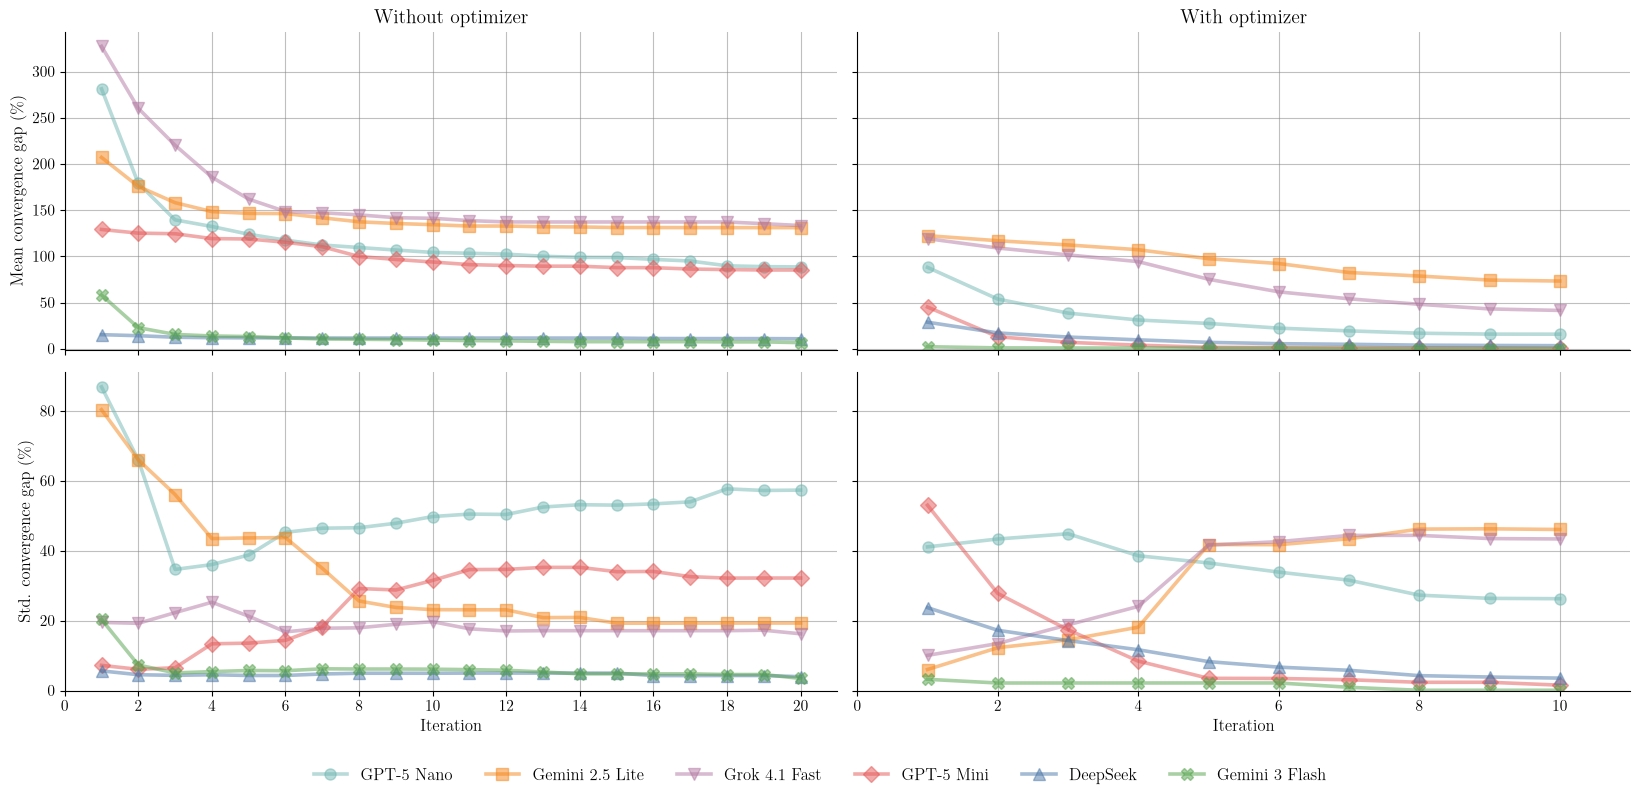

In [10]:
base_stock_baseline = (
    pd.read_excel(SOURCE_WORKBOOK, sheet_name="opt")
    .loc[:, ["dataset", "total_cost_all_basestock"]]
    .rename(columns={"total_cost_all_basestock": "base_stock_cost"})
)
base_stock_baseline["dist"] = base_stock_baseline["dataset"].str.replace(r"_(train|test)$", "", regex=True)
base_stock_baseline["mode"] = base_stock_baseline["dataset"].str.extract(r"_(train|test)$", expand=False)
base_stock_baseline = base_stock_baseline[base_stock_baseline["mode"].eq("train")].drop(columns=["dataset", "mode"])

with_optimizer_cip = convergence_with_opt_slice.merge(base_stock_baseline, on="dist", how="left")
missing_base_stock = with_optimizer_cip.loc[with_optimizer_cip["base_stock_cost"].isna(), "dist"].drop_duplicates()
if not missing_base_stock.empty:
    raise ValueError(f"Missing base-stock baseline for: {missing_base_stock.tolist()}")

with_optimizer_cip_long = with_optimizer_cip.melt(
    id_vars=result_cols + ["base_stock_cost"],
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
).dropna(subset=["repeat_top1_cost", "base_stock_cost"])
with_optimizer_cip_long["base_stock_improvement_pct"] = (
    100
    * (1 - with_optimizer_cip_long["repeat_top1_cost"] / with_optimizer_cip_long["base_stock_cost"])
)

summary_by_llm_iter = (
    with_optimizer_cip_long.groupby(["LLM", "n_pop"], dropna=False)["base_stock_improvement_pct"]
    .agg(mean="mean", std="std")
    .reset_index()
)

with_optimizer_gap = gap_long[gap_long["optimizer_status"].eq("with optimizer")].copy()
with_optimizer_gap_summary = (
    with_optimizer_gap.groupby(["LLM", "n_pop"], dropna=False)["gap_to_baseline_pct"]
    .mean()
    .reset_index(name="mean_remaining_gap_pct")
)

llm_linestyles = {
    "gpt-5-nano": "-",
    "gemini-2.5-flash-lite": "--",
    "grok-4-1-fast-non-reasoning": ":",
    "gpt-5-mini": "-.",
    "deepseek-chat": (0, (5, 1)),
    "gemini-3-flash-preview": (0, (3, 1, 1, 1)),
}

gap_curve_summary = (
    gap_to_baseline_summary.groupby(
        ["optimizer_status", "LLM", "n_pop"],
        dropna=False,
    )["mean_gap_to_baseline_pct"]
    .mean()
    .reset_index(name="avg_mean_gap_to_baseline_pct")
)

gap_std_curve_summary = (
    gap_to_baseline_summary.groupby(
        ["optimizer_status", "LLM", "n_pop"],
        dropna=False,
    )["std_gap_to_baseline_pct"]
    .mean()
    .reset_index(name="avg_std_gap_to_baseline_pct")
)

fig, axes = plt.subplots(2, 2, figsize=(16.5, 8.2), sharex="col", sharey='row')

plot_specs = [
    (axes[0, 0], gap_curve_summary, "without optimizer", "Without optimizer", "avg_mean_gap_to_baseline_pct", r"Mean convergence gap (\%)", -20, 20),
    (axes[0, 1], gap_curve_summary, "with optimizer", "With optimizer", "avg_mean_gap_to_baseline_pct", None, -20, 10),
    (axes[1, 0], gap_std_curve_summary, "without optimizer", None, "avg_std_gap_to_baseline_pct", r"Std. convergence gap (\%)", 0, 20),
    (axes[1, 1], gap_std_curve_summary, "with optimizer", None, "avg_std_gap_to_baseline_pct", None, 0, 10),
]

for ax, summary, optimizer_status, title, value_col, ylabel, y_min, x_max in plot_specs:
    panel_data = summary[summary["optimizer_status"].eq(optimizer_status)]
    for llm in SMARTNESS_ORDER:
        llm_curve = panel_data[panel_data["LLM"].eq(llm)].sort_values("n_pop")
        if llm_curve.empty:
            continue
        ax.plot(
            llm_curve["n_pop"],
            llm_curve[value_col],
            color=llm_colors([llm])[0],
            linewidth=2.6,
            marker=LLM_MARKERS[llm],
            markersize=8,
            label=LLM_LEGEND_LABELS[llm],
            alpha=.5,
        )

    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_xlim(0, x_max + 1)
    ax.set_xticks(range(0, x_max + 1, 2))
    ax.set_ylim(bottom=max(-1, y_min))
    ax.grid(True, alpha=0.5, color="gray")
    format_axis(ax, tick_size=11, label_size=12, title_size=14, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1, 0].set_xlabel(r"Iteration")
axes[1, 1].set_xlabel(r"Iteration")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.0),
    ncol=6,
    fontsize=12,
    frameon=False,
)
fig.tight_layout(rect=[0, 0.06, 1, 0.98])
fig.savefig("plots/different_llm_gap_to_baseline_mean_std_grid.pdf", bbox_inches="tight")
plt.show()


---
### With-Optimizer Cost Improvement Relative to Base-Stock

This section mirrors the cost-improvement view in `generalization_analysis.ipynb`, using the optimized base-stock policy from the `opt` sheet as the baseline. For each with-optimizer train row and repeat-level top-1 cost, cost improvement is computed as

$$
\mathrm{CIP}_{i,m,n,r}=100\left(1-\frac{C_{i,m,n,r}}{C^{\mathrm{base\ stock}}_i}\right),
$$

where positive values mean the LLM-generated policy improves on the base-stock policy for the same train instance.


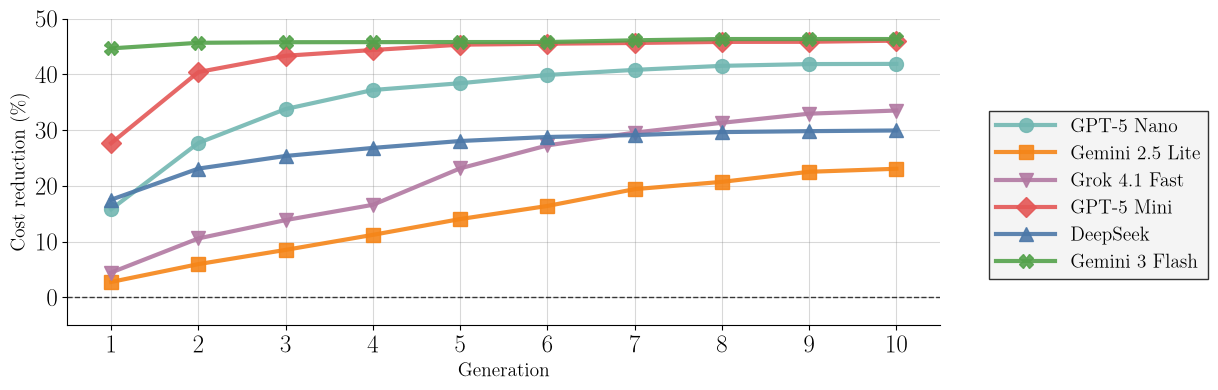

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex=True)
llm_order = [llm for llm in SMARTNESS_ORDER if llm in set(summary_by_llm_iter["LLM"])]

for llm in llm_order:
    llm_summary = summary_by_llm_iter[summary_by_llm_iter["LLM"].eq(llm)].sort_values("n_pop")
    color = llm_colors([llm])[0]
    x_vals = llm_summary["n_pop"].to_numpy(dtype=float)
    linestyle = llm_linestyles.get(llm, "-")

    ax.plot(
        x_vals,
        llm_summary["mean"],
        color=color,
        # linestyle=linestyle,
        linewidth=3.0,
        marker=LLM_MARKERS.get(llm, "o"),
        markersize=10,
        alpha=0.9,
        label=LLM_LEGEND_LABELS[llm],
    )

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)

ax.set_ylim(-5, 50.0)
ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11, 1))
ax.grid(True, axis="both", alpha=0.3, color="gray")
format_axis(ax, tick_size=18, label_size=18, title_size=18, rotation=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.82, 0.5),
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="#f2f2f2",
    fontsize=14,
    handlelength=3,
)

ax.set_xlabel("Generation", fontsize=14)
ax.set_ylabel(r"Cost reduction (\%)", fontsize=14)

fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig("plots/different_llm_with_optimizer_basestock_improvement.pdf", bbox_inches="tight")
plt.show()


---
### Spread and Convergence Gap for Selected LLMs

This section compares the standard deviation of cost improvement and the mean convergence gap across iterations for Gemini 3 Flash, DeepSeek, and GPT-5 Mini.


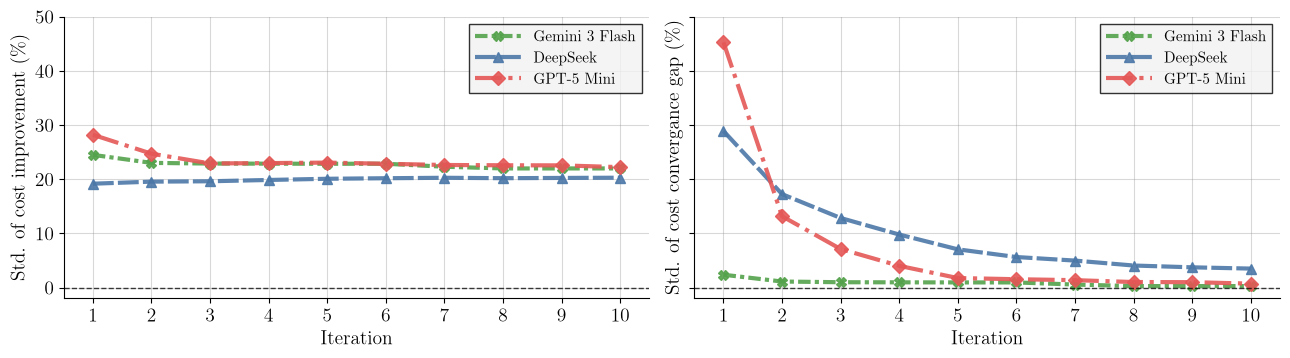

In [12]:
selected_llms = [
    "gemini-3-flash-preview",
    "deepseek-chat",
    "gpt-5-mini",
]
selected_llm_labels = [LLM_LEGEND_LABELS[llm] for llm in selected_llms]
selected_llm_styles = {llm: llm_linestyles.get(llm, "-") for llm in selected_llms}

spread_summary = summary_by_llm_iter[summary_by_llm_iter["LLM"].isin(selected_llms)].copy()
gap_summary = with_optimizer_gap_summary[with_optimizer_gap_summary["LLM"].isin(selected_llms)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True,sharey=True)

for llm in selected_llms:
    llm_spread = spread_summary[spread_summary["LLM"].eq(llm)].sort_values("n_pop")
    if llm_spread.empty:
        continue
    color = llm_colors([llm])[0]
    axes[0].plot(
        llm_spread["n_pop"],
        llm_spread["std"],
        color=color,
        linestyle=selected_llm_styles[llm],
        linewidth=3.0,
        marker=LLM_MARKERS.get(llm, "o"),
        markersize=7,
        alpha=0.9,
        label=LLM_LEGEND_LABELS[llm],
    )

for llm in selected_llms:
    llm_gap = gap_summary[gap_summary["LLM"].eq(llm)].sort_values("n_pop")
    if llm_gap.empty:
        continue
    color = llm_colors([llm])[0]
    axes[1].plot(
        llm_gap["n_pop"],
        llm_gap["mean_remaining_gap_pct"],
        color=color,
        linestyle=selected_llm_styles[llm],
        linewidth=3.0,
        marker=LLM_MARKERS.get(llm, "o"),
        markersize=7,
        alpha=0.9,
        label=LLM_LEGEND_LABELS[llm],
    )

axes[0].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)
axes[1].axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)

for ax in axes:
    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11, 1))
    ax.set_xlabel("Iteration", fontsize=14)
    ax.grid(True, axis="both", alpha=0.3, color="gray")
    format_axis(ax, tick_size=14, label_size=14, title_size=14, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_yticks([0,10,20,30,40,50])
    ax.set_yticklabels([0,10,20,30,40,50])

# axes[0].set_title("Std. of cost improvement", fontsize=15)
# axes[1].set_title("Mean convergence gap", fontsize=15)
axes[0].set_ylabel(r"Std. of cost improvement (\%)", fontsize=14)
axes[1].set_ylabel(r"Std. of cost convergance gap (\%)", fontsize=14)

legend_handles, legend_labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="#f2f2f2",
    fontsize=11,
    handlelength=3,
)

axes[1].legend(
    legend_handles,
    legend_labels,
    loc="upper right",
    ncol=1,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="#f2f2f2",
    fontsize=11,
    handlelength=3,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig("plots/different_llm_spread_and_gap_selected_models.pdf", bbox_inches="tight")
plt.show()


---
## Impact of Optimization

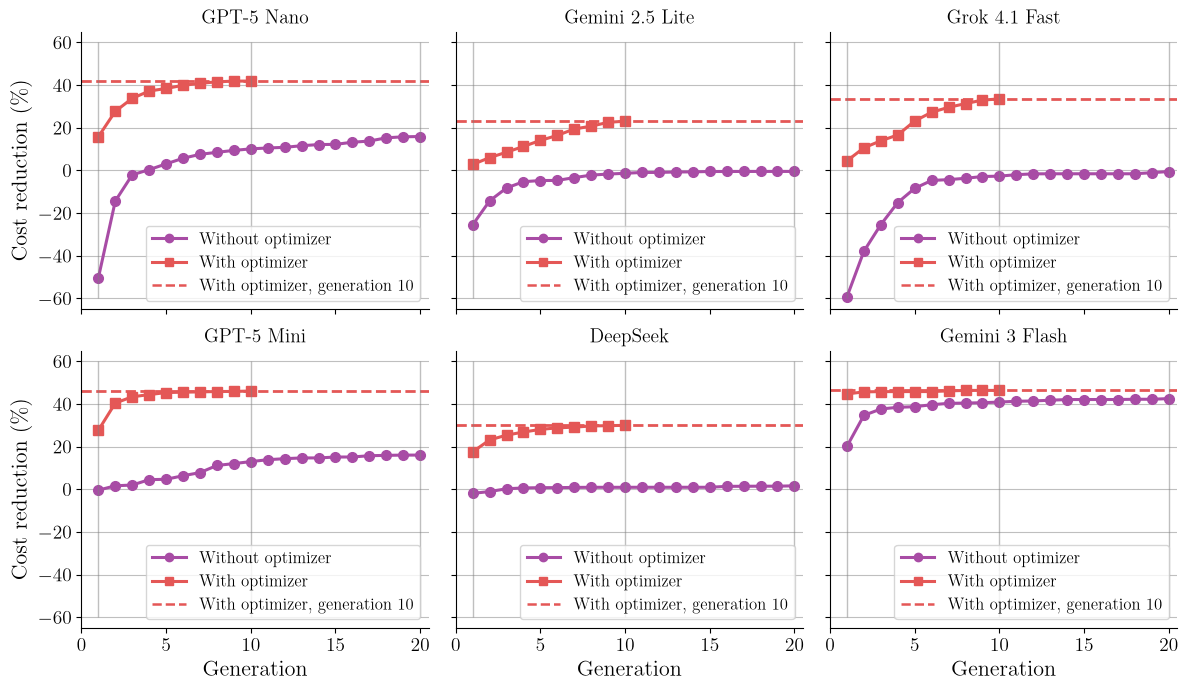

In [13]:
optimizer_line_styles = {
    "without optimizer": {
        "label": "Without optimizer",
        "color": "#A84CA5",
        "marker": "o",
        "linestyle": "-",
    },
    "with optimizer": {
        "label": "With optimizer",
        "color": "#E45756",
        "marker": "s",
        "linestyle": ":",
    },
}

cost_improvement_frame = pd.concat(
    [convergence_without_opt_slice, convergence_with_opt_slice],
    ignore_index=True,
)
base_stock_baseline = (
    pd.read_excel(SOURCE_WORKBOOK, sheet_name="opt")
    .loc[:, ["dataset", "total_cost_all_basestock"]]
    .rename(columns={"total_cost_all_basestock": "base_stock_cost"})
)
base_stock_baseline["dist"] = base_stock_baseline["dataset"].str.replace(r"_(train|test)$", "", regex=True)
base_stock_baseline["mode"] = base_stock_baseline["dataset"].str.extract(r"_(train|test)$", expand=False)
base_stock_baseline = base_stock_baseline[base_stock_baseline["mode"].eq("train")].drop(columns=["dataset", "mode"])

cost_improvement_long = cost_improvement_frame.merge(base_stock_baseline, on="dist", how="left")
missing_base_stock = cost_improvement_long.loc[cost_improvement_long["base_stock_cost"].isna(), "dist"].drop_duplicates()
if not missing_base_stock.empty:
    raise ValueError(f"Missing base-stock baseline for: {missing_base_stock.tolist()}")

cost_improvement_long = cost_improvement_long.melt(
    id_vars=result_cols + ["base_stock_cost"],
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
).dropna(subset=["repeat_top1_cost", "base_stock_cost"])
cost_improvement_long["cost_improvement_pct"] = (
    100
    * (1 - cost_improvement_long["repeat_top1_cost"] / cost_improvement_long["base_stock_cost"])
)
if "initial_basestock" in cost_improvement_long.columns:
    cost_improvement_long = cost_improvement_long.loc[cost_improvement_long["initial_basestock"].eq(100)].copy()

selected_llms = list(SMARTNESS_ORDER)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.ravel()
legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=style["color"],
        marker=style["marker"],
        # linestyle=style["linestyle"],
        lw=2.2,
        label=style["label"],
    )
    for style in optimizer_line_styles.values()
]
legend_handles.append(
    plt.Line2D(
        [0],
        [0],
        color=optimizer_line_styles["with optimizer"]["color"],
        linestyle="--",
        lw=1.8,
        label="With optimizer, generation 10",
    )
)

for ax, llm in zip(axes, selected_llms):
    llm_data = cost_improvement_long[cost_improvement_long["LLM"].eq(llm)]
    for optimizer_status, style in optimizer_line_styles.items():
        status_data = llm_data[llm_data["optimizer_status"].eq(optimizer_status)]
        mean_by_iteration = (
            status_data.dropna(subset=["n_pop", "cost_improvement_pct"])
            .groupby("n_pop")["cost_improvement_pct"]
            .mean()
            .sort_index()
        )
        if mean_by_iteration.empty:
            continue
        ax.plot(
            mean_by_iteration.index,
            mean_by_iteration.values,
            color=style["color"],
            linewidth=2.2,
            # linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=7.0,
            alpha=1,
        )

    with_optimizer_iteration_10 = llm_data.loc[
        llm_data["optimizer_status"].eq("with optimizer")
        & llm_data["n_pop"].eq(10),
        "cost_improvement_pct",
    ].mean()
    if pd.notna(with_optimizer_iteration_10):
        ax.axhline(
            with_optimizer_iteration_10,
            color=optimizer_line_styles["with optimizer"]["color"],
            linestyle="--",
            linewidth=2,
            alpha=1,
        )

    ax.set_title(LLM_LEGEND_LABELS[llm], fontsize=13)
    # ax.set_yscale("symlog", linthresh=1)
    ax.set_xlim(0, 20.5)
    ax.set_xticks(range(0, 21, 5))
    ax.set_ylim(-65, 65)
    ax.set_yticks(range(-60, 61,20))
    ax.grid(True, axis="y", alpha=0.5, color="gray")
    format_axis(ax, tick_size=14, label_size=14, title_size=14, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        handles=legend_handles,
        loc="lower right",
        # bbox_to_anchor=(0.5, 0),
        ncol=1,
        fontsize=12,
        frameon=True,
        )
    ax.vlines(x=1, ymin=-60, ymax=60, color="gray", linestyle="-", linewidth=1.0, alpha=0.5)
    ax.vlines(x=10, ymin=-60, ymax=60, color="gray", linestyle="-", linewidth=1.0, alpha=0.5)
    ax.vlines(x=20, ymin=-60, ymax=60, color="gray", linestyle="-", linewidth=1.0, alpha=0.5)

axes[0].set_ylabel(r"Cost reduction (\%)", fontsize=16)
for ax in axes[3:]:
    ax.set_xlabel("Generation", fontsize=16)
for ax in axes[::3]:
    ax.set_ylabel(r"Cost reduction (\%)", fontsize=16)


fig.tight_layout()
fig.savefig("plots/different_llm_cost_improvement_with_and_without_optimization.pdf", bbox_inches="tight")
plt.show()


#### Train Table

In [16]:
cost_reduction_summary = (
    cost_improvement_long.groupby(
        ["LLM", "n_pop", "optimizer_status"],
        dropna=False,
    )["cost_improvement_pct"]
    .agg(
        mean_cost_reduction_pct="mean",
        std_cost_reduction_pct="std",
    )
    .reset_index()
)

optimizer_summary_table = cost_reduction_summary.pivot(
    index=["LLM", "n_pop"],
    columns="optimizer_status",
    values=["mean_cost_reduction_pct", "std_cost_reduction_pct"],
)
summary_column_order = [
    ("mean_cost_reduction_pct", "without optimizer"),
    ("std_cost_reduction_pct", "without optimizer"),
    ("mean_cost_reduction_pct", "with optimizer"),
    ("std_cost_reduction_pct", "with optimizer"),
]
optimizer_summary_table = (
    optimizer_summary_table.reindex(
        columns=pd.MultiIndex.from_tuples(summary_column_order)
    )
    .set_axis(
        [
            "Without optimizer mean (%)",
            "Without optimizer std. dev. (%)",
            "With optimizer mean (%)",
            "With optimizer std. dev. (%)",
        ],
        axis=1,
    )
    .reset_index()
)
optimizer_summary_table["LLM_order"] = optimizer_summary_table["LLM"].map(
    {llm: rank for rank, llm in enumerate(SMARTNESS_ORDER)}
)
optimizer_summary_table = (
    optimizer_summary_table.sort_values(["LLM_order", "n_pop"])
    .drop(columns="LLM_order")
    .rename(columns={"LLM": "LLM backbone", "n_pop": "Iteration"})
)
optimizer_summary_table["LLM backbone"] = optimizer_summary_table[
    "LLM backbone"
].map(LLM_LEGEND_LABELS)

display(optimizer_summary_table.round(2))
optimizer_summary_table.round(2).to_csv(
    "plots/different_llm_cost_improvement_with_and_without_optimization.csv",
    index=False,
)


,LLM backbone,Iteration,Without optimizer mean (%),Without optimizer std. dev. (%),With optimizer mean (%),With optimizer std. dev. (%)
80,GPT-5 Nano,1,-50.38,56.14,15.82,16.56
81,GPT-5 Nano,2,-14.34,33.01,27.71,19.92
82,GPT-5 Nano,3,-2.08,17.12,33.79,21.57
83,GPT-5 Nano,4,0.34,16.70,37.21,21.06
84,GPT-5 Nano,5,3.05,16.85,38.42,21.00
...,...,...,...,...,...,...
55,Gemini 3 Flash,16,42.07,24.39,NaN,NaN
56,Gemini 3 Flash,17,42.07,24.39,NaN,NaN
57,Gemini 3 Flash,18,42.19,24.38,NaN,NaN
58,Gemini 3 Flash,19,42.19,24.38,NaN,NaN


#### Test Table

In [18]:
test_source_sheets = [
    "S 4.1",
    "S 3",
    "S 4.4",
    "S 4.4 no opt",
]
test_cost_improvement_frame = df.loc[
    df["source_sheet"].isin(test_source_sheets)
    & df["mode"].astype(str).str.lower().eq("test")
    & df["initial_basestock"].eq(100)
].copy()

test_base_stock_baseline = (
    pd.read_excel(SOURCE_WORKBOOK, sheet_name="opt")
    .loc[:, ["dataset", "total_cost_all_basestock"]]
    .rename(columns={"total_cost_all_basestock": "base_stock_cost"})
)
test_base_stock_baseline["dist"] = test_base_stock_baseline["dataset"].str.replace(
    r"_(train|test)$", "", regex=True
)
test_base_stock_baseline["mode"] = test_base_stock_baseline["dataset"].str.extract(
    r"_(train|test)$", expand=False
)
test_base_stock_baseline = test_base_stock_baseline.loc[
    test_base_stock_baseline["mode"].eq("test"),
    ["dist", "base_stock_cost"],
]

test_cost_improvement_long = test_cost_improvement_frame.merge(
    test_base_stock_baseline,
    on="dist",
    how="left",
).melt(
    id_vars=["LLM", "optimizer_status", "n_pop", "base_stock_cost"],
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
).dropna(subset=["repeat_top1_cost", "base_stock_cost"])
test_cost_improvement_long["cost_improvement_pct"] = (
    100
    * (1 - test_cost_improvement_long["repeat_top1_cost"] / test_cost_improvement_long["base_stock_cost"])
)

test_generation_selection = (
    ((test_cost_improvement_long["optimizer_status"] == "with optimizer")
     & test_cost_improvement_long["n_pop"].eq(10))
    | ((test_cost_improvement_long["optimizer_status"] == "without optimizer")
       & test_cost_improvement_long["n_pop"].eq(20))
)
test_table = (
    test_cost_improvement_long.loc[test_generation_selection]
    .groupby(["LLM", "optimizer_status", "n_pop"], dropna=False)["cost_improvement_pct"]
    .agg(
        min="min",
        max="max",
        mean="mean",
        std_dev="std",
    )
    .reset_index()
    .rename(
        columns={
            "LLM": "LLM backbone",
            "optimizer_status": "Optimizer status",
            "n_pop": "Generation",
            "std_dev": "Std. dev. (%)",
        }
    )
)
test_table["LLM backbone"] = test_table["LLM backbone"].map(LLM_LEGEND_LABELS)
test_table = test_table.rename(
    columns={
        "min": "Min (%)",
        "max": "Max (%)",
        "mean": "Mean (%)",
    }
)
test_table = test_table.sort_values(["LLM backbone", "Optimizer status"])

display(test_table.round(2))

,LLM backbone,Optimizer status,Generation,Min (%),Max (%),Mean (%),Std. dev. (%)
0,DeepSeek,with optimizer,10,4.46,73.20,29.44,20.28
1,DeepSeek,without optimizer,20,-4.16,22.72,0.65,4.43
6,GPT-5 Mini,with optimizer,10,12.53,73.24,45.37,23.37
7,GPT-5 Mini,without optimizer,20,-1.07,63.67,14.95,16.61
8,GPT-5 Nano,with optimizer,10,12.99,73.20,41.26,21.68
9,GPT-5 Nano,without optimizer,20,-81.43,63.83,14.79,23.89
2,Gemini 2.5 Lite,with optimizer,10,-7.21,72.77,21.17,21.72
3,Gemini 2.5 Lite,without optimizer,20,-49.58,0.68,-1.49,9.09
4,Gemini 3 Flash,with optimizer,10,17.26,73.20,45.61,23.20
5,Gemini 3 Flash,without optimizer,20,9.24,73.10,41.86,25.19


---
### With-Optimizer Speed and Reliability to Within 5\% of Best Cost
---

This section focuses only on rows with the optimizer enabled. To make the LLM comparison fair, it uses only the problem instances that appear for every with-optimizer LLM. The goal is to separate two related questions: how quickly an LLM gets close to the best observed cost on average, and how often it gets close at all.

For each instance $i$, keep the same best-repeat baseline used above:

$$
B_i = \min_{m,o,n,r} C_{i,m,o,n,r}.
$$

For a fixed LLM $m$ with optimizer enabled, first average the 10 repeat-level top-1 costs at each iteration:

$$
\bar{C}_{i,m,n} = \frac{1}{10}\sum_{r=1}^{10} C_{i,m,o=\mathrm{with},n,r}.
$$

Because this is a cost-minimization problem, "within 95\% of the best cost" is operationalized as being no more than 5\% above the best observed cost. Equivalently, the average top-1 cost at that iteration must satisfy

$$
\bar{C}_{i,m,n} \le 1.05 B_i.
$$

The speed metric is the first iteration at which the LLM reaches this within-5\%-of-best threshold:

$$
\tau^{95}_{i,m} = \min \{ n_{\mathrm{pop}} : \bar{C}_{i,m,n} \le 1.05 B_i \}.
$$

If the model never gets within 5\% of $B_i$ for that instance, $\tau^{95}_{i,m}$ is missing. The left plot reports the median of $\tau^{95}_{i,m}$ across only the instances where the model succeeds, so smaller is faster.

The reliability metric is the threshold-reaching rate:

$$
\mathrm{reliability}_m = 100 \times \frac{\#\{i : \tau^{95}_{i,m}\ \mathrm{exists}\}}{\#\{i\}}.
$$

The right plot reports this reliability percentage. A model can be fast but unreliable if it gets close quickly on only a few instances; a model can be reliable but slower if it gets close on many instances but needs more iterations.


In [13]:
WITHIN_BEST_GAP_PCT = 5  # Change this threshold to adjust the speed/reliability criterion.
WITHIN_BEST_MULTIPLIER = 1 + WITHIN_BEST_GAP_PCT / 100
WITHIN_BEST_GAP_LABEL = f"{WITHIN_BEST_GAP_PCT}%"

with_opt_gap = gap_long[gap_long["optimizer_status"].eq("with optimizer")].copy()
if "initial_basestock" in with_opt_gap.columns:
    with_opt_gap = with_opt_gap.loc[with_opt_gap["initial_basestock"].eq(100)].copy()
with_opt_llms = [llm for llm in SMARTNESS_ORDER if llm in set(with_opt_gap["LLM"])]
n_with_opt_llms = len(with_opt_llms)
with_opt_instance_llm_cols = instance_cols + ["LLM"]

with_opt_common_instances = (
    with_opt_gap[instance_cols + ["LLM"]]
    .drop_duplicates()
    .groupby(instance_cols, dropna=False)["LLM"]
    .nunique()
    .rename("n_llms")
    .reset_index()
    .query("n_llms == @n_with_opt_llms")
    .drop(columns="n_llms")
)
with_opt_gap_common = with_opt_gap.merge(with_opt_common_instances, on=instance_cols, how="inner")

with_opt_iteration_mean = (
    with_opt_gap_common.groupby(with_opt_instance_llm_cols + ["n_pop"], dropna=False)
    .agg(
        iteration_mean_top1_cost=("repeat_top1_cost", "mean"),
        baseline_best_repeat_cost=("baseline_best_repeat_cost", "first"),
    )
    .reset_index()
)
with_opt_iteration_mean["within_best_threshold"] = (
    with_opt_iteration_mean["iteration_mean_top1_cost"]
    <= WITHIN_BEST_MULTIPLIER * with_opt_iteration_mean["baseline_best_repeat_cost"]
)

with_opt_first_within_threshold = (
    with_opt_iteration_mean[with_opt_iteration_mean["within_best_threshold"]]
    .groupby(with_opt_instance_llm_cols, dropna=False)["n_pop"]
    .min()
    .rename("first_within_best_n_pop")
    .reset_index()
)
with_opt_first_within_threshold = (
    with_opt_iteration_mean[with_opt_instance_llm_cols]
    .drop_duplicates()
    .merge(with_opt_first_within_threshold, on=with_opt_instance_llm_cols, how="left")
)
with_opt_first_within_threshold["within_best_threshold"] = with_opt_first_within_threshold["first_within_best_n_pop"].notna()

with_opt_speed_reliability = (
    with_opt_first_within_threshold.groupby("LLM", dropna=False)
    .agg(
        median_first_within_best_n_pop=("first_within_best_n_pop", "median"),
        mean_first_within_best_n_pop=("first_within_best_n_pop", "mean"),
        n_instances=("within_best_threshold", "size"),
        n_within_threshold=("within_best_threshold", "sum"),
    )
    .reset_index()
)
with_opt_speed_reliability["within_threshold_rate_pct"] = (
    100 * with_opt_speed_reliability["n_within_threshold"] / with_opt_speed_reliability["n_instances"]
)
with_opt_speed_reliability["LLM_label"] = with_opt_speed_reliability["LLM"].map(LLM_LEGEND_LABELS)
with_opt_speed_reliability = with_opt_speed_reliability.sort_values(
    "LLM",
    key=lambda values: values.map({llm: idx for idx, llm in enumerate(SMARTNESS_ORDER)}),
)

# display(
#     with_opt_speed_reliability[
#         [
#             "LLM_label",
#             "median_first_within_best_n_pop",
#             "mean_first_within_best_n_pop",
#             "within_threshold_rate_pct",
#             "n_within_threshold",
#             "n_instances",
#         ]
#     ].round(2)
# )


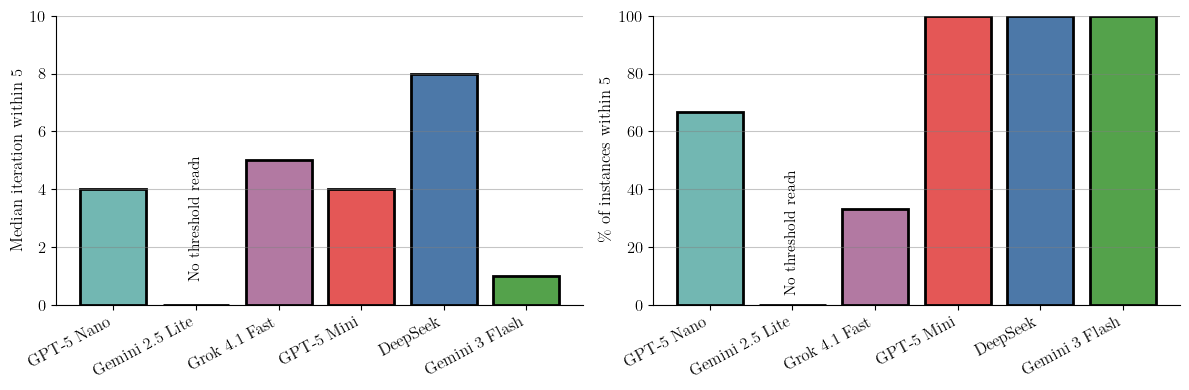

In [14]:
plot_data = with_opt_speed_reliability.set_index("LLM").reindex(
    [llm for llm in SMARTNESS_ORDER if llm in set(with_opt_speed_reliability["LLM"])]
)
plot_labels = [LLM_LEGEND_LABELS[llm] for llm in plot_data.index]
plot_colors = llm_colors(plot_data.index)
x_positions = range(len(plot_data))

FONT_SIZE = 12
ANNOTATION_FONT_SIZE = 11
speed_ylabel = rf"Median iteration within {WITHIN_BEST_GAP_LABEL} of best cost"
reliability_ylabel = rf"$\%$ of instances within {WITHIN_BEST_GAP_LABEL} of best cost"

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax in axes:
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(plot_labels, rotation=28, ha="right")
    ax.grid(True, axis="y", alpha=0.45, color="gray")
    format_axis(ax, tick_size=FONT_SIZE, label_size=FONT_SIZE, title_size=FONT_SIZE, rotation=28)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

speed_values = plot_data["median_first_within_best_n_pop"].fillna(0)
axes[0].bar(
    x_positions,
    speed_values,
    color=plot_colors,
    edgecolor="black",
    linewidth=2,
    alpha=1,
)
for x_pos, first_within_best in zip(x_positions, plot_data["median_first_within_best_n_pop"]):
    if pd.isna(first_within_best):
        axes[0].text(x_pos, 0.8, "No threshold reach", ha="center", va="bottom", rotation=90, fontsize=ANNOTATION_FONT_SIZE)
# axes[0].set_title("Speed: median first threshold-reaching iteration")
axes[0].set_ylabel(speed_ylabel, fontsize=FONT_SIZE)
axes[0].set_ylim(0, 10)
axes[0].set_yticks(range(0, 12, 2))

axes[1].bar(
    x_positions,
    plot_data["within_threshold_rate_pct"],
    color=plot_colors,
    edgecolor="black",
    linewidth=2,
    alpha=1,
)
for x_pos, n_within_threshold in zip(x_positions, plot_data["n_within_threshold"]):
    if n_within_threshold == 0:
        axes[1].text(x_pos, 3, "No threshold reach", ha="center", va="bottom", rotation=90, fontsize=ANNOTATION_FONT_SIZE)
# axes[1].set_title("Reliability: threshold-reaching rate")
axes[1].set_ylabel(reliability_ylabel, fontsize=FONT_SIZE)
axes[1].set_ylim(0, 100)
axes[1].set_yticks(range(0, 101, 20))



fig.tight_layout()
fig.savefig("plots/different_llm_with_optimizer_speed_reliability.pdf", bbox_inches="tight")
plt.show()


---
### LLM Comparison Across Starting Base-Stock Values

This final figure uses only the `S 4.4 no opt extension` train rows, where the starting base-stock level varies. Each panel fixes one starting base-stock value and compares the LLMs across iteration, using the same base-stock baseline as the rest of the notebook.


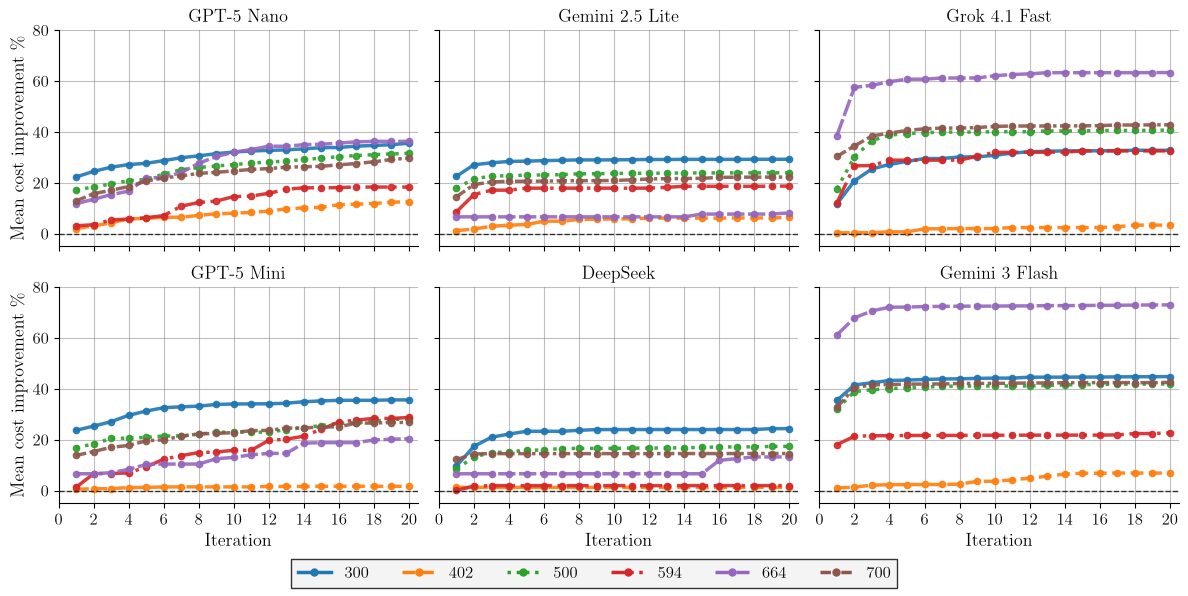

In [28]:
extension_df = df.loc[
    df["source_sheet"].eq("S 4.4 no opt extension")
    & df["mode"].astype(str).str.lower().eq("train")
].copy()

extension_base_stock = (
    extension_df[["initial_basestock", "dist", "avg_all"]]
    .dropna(subset=["initial_basestock", "dist", "avg_all"])
    .drop_duplicates(subset=["initial_basestock", "dist"])
    .rename(columns={"avg_all": "base_stock_cost"})
)

extension_cip = extension_df.merge(extension_base_stock, on=["initial_basestock", "dist"], how="left")
missing_extension_baseline = extension_cip.loc[extension_cip["base_stock_cost"].isna(), ["initial_basestock", "dist"]].drop_duplicates()
if not missing_extension_baseline.empty:
    raise ValueError(
        "Missing base-stock baseline for extension slice: "
        f"{missing_extension_baseline.to_dict(orient='records')}"
    )

extension_cip_long = extension_cip.melt(
    id_vars=["LLM", "initial_basestock", "n_pop", "base_stock_cost"],
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
).dropna(subset=["repeat_top1_cost", "base_stock_cost", "initial_basestock"])
extension_cip_long["base_stock_improvement_pct"] = (
    100
    * (1 - extension_cip_long["repeat_top1_cost"] / extension_cip_long["base_stock_cost"])
)

extension_summary = (
    extension_cip_long.groupby(["LLM", "initial_basestock", "n_pop"], dropna=False)["base_stock_improvement_pct"]
    .mean()
    .reset_index(name="mean_base_stock_improvement_pct")
)

initial_basestock_order = sorted(extension_summary["initial_basestock"].dropna().unique())
llm_order = [llm for llm in SMARTNESS_ORDER if llm in set(extension_summary["LLM"])]

INIT_MARKERS = {
    "300": "o",
    "402": "s",
    "500": "v",
    "594": "D",
    "664": "^",
    "700": "X",
}

bs_palette = plt.get_cmap("tab10")
bs_colors = {bs: bs_palette(idx % 10) for idx, bs in enumerate(initial_basestock_order)}
bs_linestyles = {
    300: "-",
    402: "--",
    500: ":",
    594: "-.",
    664: (0, (5, 1)),
    700: (0, (3, 1, 1, 1)),
}

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, llm in zip(axes, llm_order):
    panel = extension_summary[extension_summary["LLM"].eq(llm)]
    for initial_basestock in initial_basestock_order:
        llm_curve = panel[panel["initial_basestock"].eq(initial_basestock)].sort_values("n_pop")
        if llm_curve.empty:
            continue
        ax.plot(
            llm_curve["n_pop"],
            llm_curve["mean_base_stock_improvement_pct"],
            color=bs_colors[initial_basestock],
            linestyle=bs_linestyles.get(int(initial_basestock), "-"),
            linewidth=2.5,
            marker=INIT_MARKERS.get(llm, "o"),
            markersize=4.5,
            alpha=0.9,
            label=f"{int(initial_basestock)}",
        )

    ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)
    ax.set_title(LLM_LEGEND_LABELS[llm], fontsize=14)
    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(-5, 80)
    ax.set_xticks(range(0, 21, 2))
    ax.grid(True, axis="both", alpha=0.5, color="gray")
    format_axis(ax, tick_size=12, label_size=12, title_size=13, rotation=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[3:]:
    ax.set_xlabel("Iteration", fontsize=13)
for ax in axes[::3]:
    ax.set_ylabel(r"Mean cost improvement \%", fontsize=13)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=bs_colors[bs],
        linestyle=bs_linestyles.get(int(bs), "-"),
        linewidth=2.5,
        marker="o",
        markersize=5,
        label=f"{int(bs)}",
    )
    for bs in initial_basestock_order
]
fig.legend(
    legend_handles,
    [f"{int(bs)}" for bs in initial_basestock_order],
    loc="lower center",
    ncol=6,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="#f2f2f2",
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig("plots/different_llm_initial_basestock_comparison.pdf", bbox_inches="tight")
plt.show()


---
### Selected LLMs Across Starting Base-Stock Values

This section focuses on Gemini 3 Flash, DeepSeek, and GPT-5 Mini across the varying starting base-stock values in `S 4.4 no opt extension`. The top row shows mean cost improvement relative to the base-stock baseline, and the bottom row shows mean convergence gap to the best observed repeat-level cost for the same extension slice.


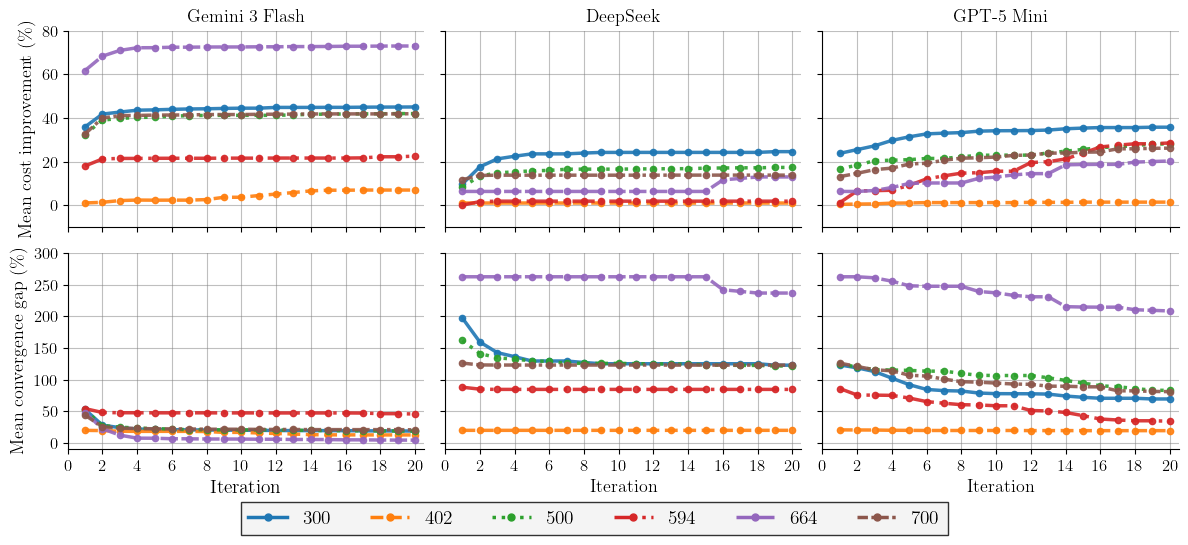

In [16]:
selected_extension_llms = [
    "gemini-3-flash-preview",
    "deepseek-chat",
    "gpt-5-mini",
]

extension_selected_summary = extension_summary[extension_summary["LLM"].isin(selected_extension_llms)].copy()

extension_gap_frame = extension_df.copy()
extension_gap_instance_cols = [
    col
    for col in ["problem", "n_train", "p", "initial", "dist", "initial_basestock"]
    if col in extension_gap_frame.columns
]
extension_gap_result_cols = extension_gap_instance_cols + ["LLM", "n_pop"]

extension_gap_baseline = (
    extension_gap_frame.groupby(extension_gap_instance_cols, dropna=False)[top1_repeat_cols]
    .min()
    .min(axis=1)
    .rename("baseline_best_repeat_cost")
    .reset_index()
)

extension_gap_long = extension_gap_frame.melt(
    id_vars=extension_gap_result_cols,
    value_vars=top1_repeat_cols,
    var_name="repeat",
    value_name="repeat_top1_cost",
)
extension_gap_long = extension_gap_long.merge(extension_gap_baseline, on=extension_gap_instance_cols, how="left")
extension_gap_long["gap_to_baseline_pct"] = (
    100
    * (extension_gap_long["repeat_top1_cost"] - extension_gap_long["baseline_best_repeat_cost"])
    / extension_gap_long["baseline_best_repeat_cost"]
)
extension_gap_summary = (
    extension_gap_long.groupby(["LLM", "initial_basestock", "n_pop"], dropna=False)["gap_to_baseline_pct"]
    .mean()
    .reset_index(name="mean_gap_to_baseline_pct")
)

extension_selected_gap_summary = extension_gap_summary[
    extension_gap_summary["LLM"].isin(selected_extension_llms)
].copy()
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True, sharey="row")

for col_idx, llm in enumerate(selected_extension_llms):
    llm_label = LLM_LEGEND_LABELS[llm]
    ax_top = axes[0, col_idx]
    ax_bottom = axes[1, col_idx]

    llm_improvement = extension_selected_summary[extension_selected_summary["LLM"].eq(llm)]
    llm_gap = extension_selected_gap_summary[extension_selected_gap_summary["LLM"].eq(llm)]

    for initial_basestock in initial_basestock_order:
        improvement_curve = llm_improvement[llm_improvement["initial_basestock"].eq(initial_basestock)].sort_values("n_pop")
        if not improvement_curve.empty:
            ax_top.plot(
                improvement_curve["n_pop"],
                improvement_curve["mean_base_stock_improvement_pct"],
                color=bs_colors[initial_basestock],
                linestyle=bs_linestyles.get(int(initial_basestock), "-"),
                linewidth=2.5,
                marker="o",
                markersize=4.5,
                alpha=0.9,
                label=f"{int(initial_basestock)}",
            )

        gap_curve = llm_gap[llm_gap["initial_basestock"].eq(initial_basestock)].sort_values("n_pop")
        if not gap_curve.empty:
            ax_bottom.plot(
                gap_curve["n_pop"],
                gap_curve["mean_gap_to_baseline_pct"],
                color=bs_colors[initial_basestock],
                linestyle=bs_linestyles.get(int(initial_basestock), "-"),
                linewidth=2.5,
                marker="o",
                markersize=4.5,
                alpha=0.9,
                label=f"{int(initial_basestock)}",
            )

    # ax_top.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)
    # ax_bottom.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.75)
    # ax_bottom.axhline(1, color="black", linewidth=1.0, linestyle="--", alpha=0.55)
    ax_top.set_title(llm_label, fontsize=14)
    # ax_bottom.set_title(llm_label, fontsize=14)
    ax_top.set_ylim(-10, 80)
    ax_top.set_yticks(range(0, 81, 20))
    ax_bottom.set_ylim(-10, 300)
    ax_bottom.set_yticks(range(0, 301, 50))

    for ax in (ax_top, ax_bottom):
        ax.set_xlim(0.5, 20.5)
        ax.set_xticks(range(0, 21, 2))
        ax.grid(True, axis="both", alpha=0.5, color="gray")
        format_axis(ax, tick_size=12, label_size=12, title_size=13, rotation=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

axes[1, 0].set_xlabel("Iteration", fontsize=14)
axes[1, 1].set_xlabel("Iteration", fontsize=13)
axes[1, 2].set_xlabel("Iteration", fontsize=13)
axes[0, 0].set_ylabel(r"Mean cost improvement (\%)", fontsize=13)
axes[1, 0].set_ylabel(r"Mean convergence gap (\%)", fontsize=13)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        color=bs_colors[bs],
        linestyle=bs_linestyles.get(int(bs), "-"),
        linewidth=2.5,
        marker="o",
        markersize=5,
        label=f"{int(bs)}",
    )
    for bs in initial_basestock_order
]
fig.legend(
    legend_handles,
    [f"{int(bs)}" for bs in initial_basestock_order],
    loc="lower center",
    ncol=min(6, len(initial_basestock_order)),
    frameon=True,
    fancybox=False,
    edgecolor="black",
    facecolor="#f2f2f2",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig("plots/different_llm_extension_selected_llms_improvement_gap.pdf", bbox_inches="tight")
plt.show()
